In [5]:
# 1. Define your base hardware parameters
d = 5  # Surface code distance (can be 5, 7, 9, etc.)
t_c = 1e-6  # Cycle time (1 microsecond)
p_phys = 1e-3  # Physical error rate (0.1%)

# 2. Calculate the baseline logical error rate per cycle
# Typical empirical scaling for surface code: p_L ~ 0.1 * (100 * p_phys)^((d+1)/2)
p_L = 0.1 * (100 * p_phys)**((d + 1) / 2)

# 3. Build the profile

top = {
        "type": "tiled_k_nearest",
        "n_blocks_row": 4,
        "n_blocks_col": 4,
        "n" : 5,
        "m": 5,
        "k_intra":2,
        "k_inter": 4,
        
    }

top2 = {
    "type": "heavy_hex",
    "n_blocks_row": 4,
    "n_blocks_col": 4,
    "d": 3,
}
# currently working on making it networkable !
profile = {
    "sq_gates": {
        "HGate": {
            "error": d * p_L, 
            "duration": d * t_c
        },
        "TGate": {
            "error": p_L, 
            "duration": 15 * d * t_c  # Absorbs the heavy cycle cost of MSD 
        }
    },
    "two_q_gates": {
        "CXGate": {
            "local_error": d * p_L, 
            "local_duration": d * t_c
        }
    },
    "inter_device_gates": {
        "SwapGate": {
            # Represents inter-block logical teleportation or long-range lattice surgery
            # Typically requires slightly higher overhead than local patch surgery
            "inter_error": 2 * d * p_L, 
            "inter_duration": 2 * d * t_c
        }
    }
}

args = {"topology": top, "profile": profile}

In [2]:

from backend.FaultTolerantTarget import FTTarget

In [3]:
targ = FTTarget(args)

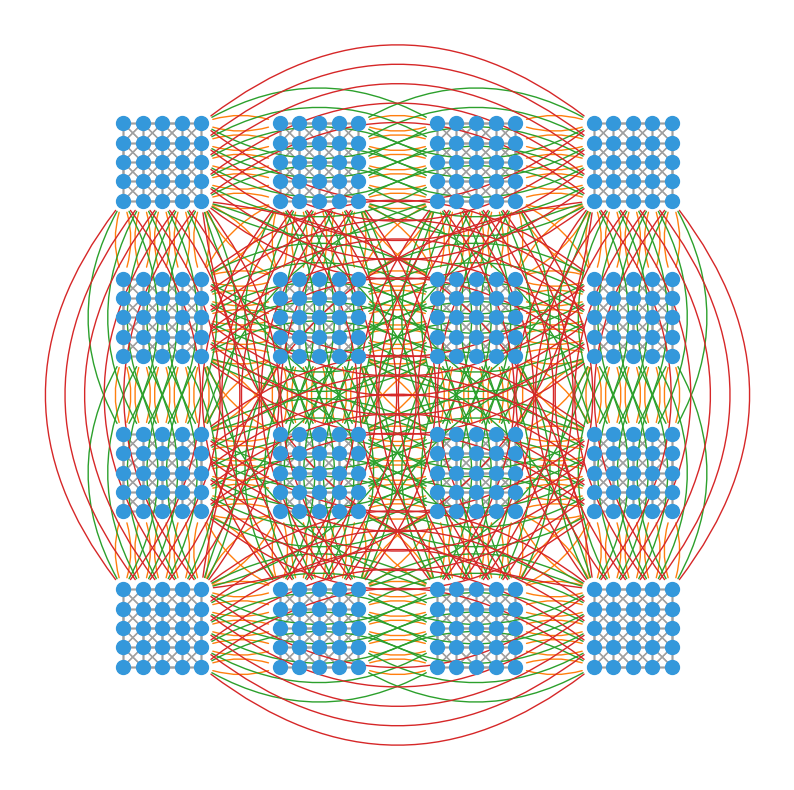

In [4]:
targ.plot()

In [ ]:
args2 = {"topology": top2, "profile": profile}
targs2 = FTTarget(args2)